In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [55]:
# load the dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv"
df = pd.read_csv(url)

### Dataset overview

In [56]:
df

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [57]:
# Rename columns to something manageable
df.columns = ['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer',
              'CoarseAggregate', 'FineAggregate', 'Age', 'Strength']

In [58]:
df

,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [59]:
print(df.shape)
print(df.isnull().sum())  # All zeros — no missing values
print(df.describe())

(1030, 9)
Cement              0
Slag                0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAggregate     0
FineAggregate       0
Age                 0
Strength            0
dtype: int64
            Cement         Slag       FlyAsh        Water  Superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.400000   200.100000   247.000000         32.200000   

       CoarseAggregate  FineAggregate          Age     Strength  
c

- all dtypes are numeric
- no missing values

### Dataset Overview

- Cement (kg/m³)  
- Blast Furnace Slag (kg/m³)  
- Fly Ash (kg/m³)  
- Water (kg/m³)  
- Superplasticizer (kg/m³)  
- Coarse Aggregate (kg/m³)  
- Fine Aggregate (kg/m³)  
- Age (days, 1–365)  
- Target: Concrete compressive strength (MPa) 

### EDA

#### Correlation heatmap

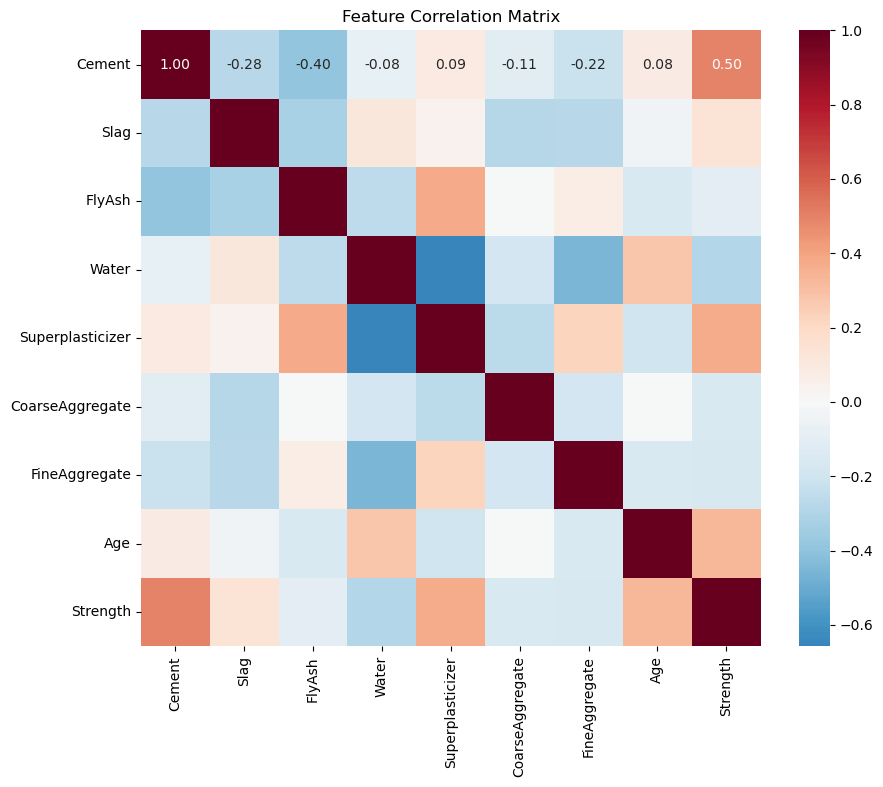

In [60]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [61]:
df.corr()

,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
Cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
Slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
FlyAsh,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
Water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
Superplasticizer,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
CoarseAggregate,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
FineAggregate,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
Age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
Strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


- Cement positively correlated with Strength
- Water negatively correlated with Strength
- Age positively correlated (concrete cures over time)

#### Target Distribution

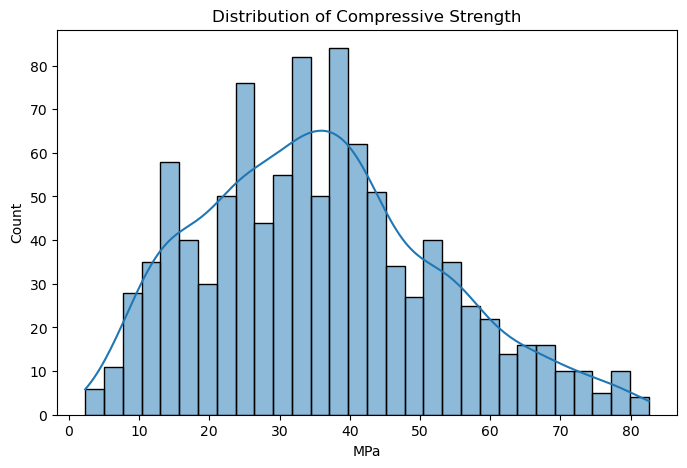

In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Strength'], bins=30, kde=True)
plt.title('Distribution of Compressive Strength')
plt.xlabel('MPa')
plt.show()

Key Insights:
- The distribution centers roughly between 30 and 40 MPa
- Wide Variation:The lowest recorded strength is around 5–6 MPa, the highest reaches past 80 MPa.
- Not Perfectly Normal
- The distribution has a right (positive) skew

#### Scatter plot Cement vs Strength

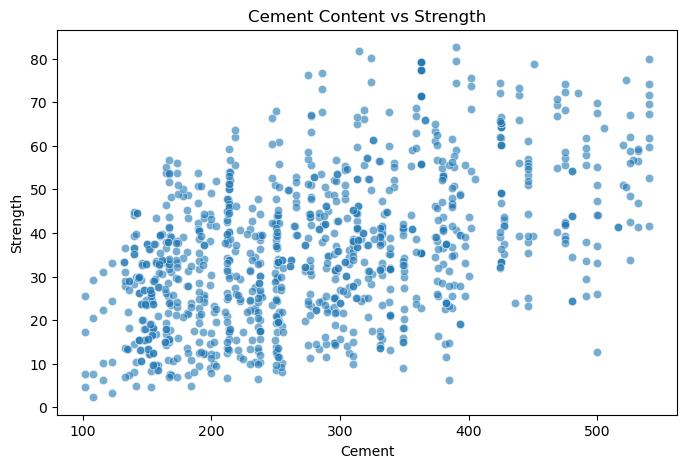

In [63]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x = 'Cement', y = 'Strength', data=df, alpha=0.6)
plt.title('Cement Content vs Strength')
plt.show()

Key insights:

- Clear positive correlation(higher cement levels associated with greater strength values)
- Increasing Variance(While the trend is positive, the reliability decreases as cement content gets higher)

### Feature sets

In [64]:
# A. Originals features only
features_original = ['Cement', 'Slag', 'FlyAsh', 'Water', 
                     'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Age']

In [65]:
# B. All engineered features
df['Water_Cement_ratio'] = df['Water'] / (df['Cement'] + 1e-6)
df['Total_Binder'] = df['Cement'] + df['Slag'] + df['FlyAsh']
df['Water_Binder_ratio'] = df['Water'] / (df['Total_Binder'] + 1e-6)
df['Aggregate_ratio'] = df['FineAggregate'] / (df['CoarseAggregate'] + 1e-6)
df['Log_Age'] = np.log1p(df['Age'])

features_all = features_original + ['Water_Cement_ratio', 'Total_Binder', 
                                    'Water_Binder_ratio', 'Aggregate_ratio', 'Log_Age']

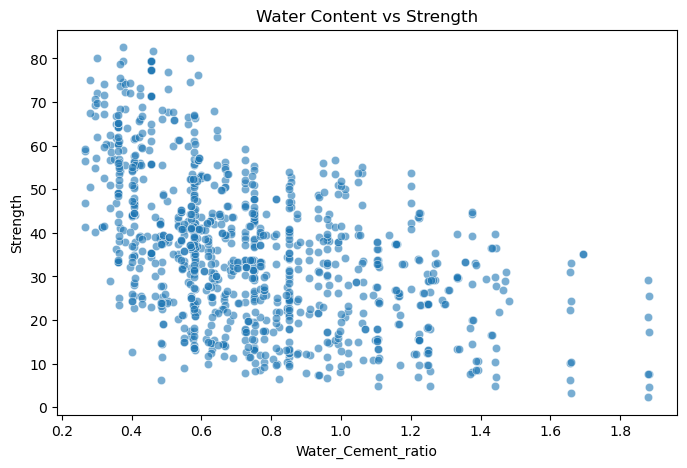

In [66]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Water_Cement_ratio', y='Strength', data=df, alpha=0.6)
plt.title('Water Content vs Strength')
plt.show()

Water-to-Cement Ratio, often considered the most important factor in concrete mix design (known as Abrams' Law)

In [67]:
# C. VIF-cleaned features(iteratively dropped high-VIF features)
features_vif = ['Superplasticizer', 'Water_Cement_ratio', 'Total_Binder', 'Aggregate_ratio', 'Log_Age']

In [68]:
feature_sets = {
    'original': features_original,
    'all_features': features_all,
    'vif_cleaned': features_vif
}

### VIF Analysis for each set

In [69]:
print("\n" + "="*60)
print("VIF ANALYSIS")
print("="*60)

for name, features in feature_sets.items():
    X_vif = df[features]
    X_const = sm.add_constant(X_vif)
    
    vif_data = pd.DataFrame({
        'Feature': X_vif.columns,
        'VIF': [variance_inflation_factor(X_const.values, i+1) 
                for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False)
    
    print(f"\n--- {name.upper()} ({len(features)} features) ---")
    print(vif_data.to_string(index=False))
    print(f"Max VIF: {vif_data['VIF'].max():.2f} | Mean VIF: {vif_data['VIF'].mean():.2f}")


VIF ANALYSIS

--- ORIGINAL (8 features) ---
         Feature      VIF
          Cement 7.488944
            Slag 7.276963
   FineAggregate 7.005081
           Water 7.003957
          FlyAsh 6.170634
 CoarseAggregate 5.074617
Superplasticizer 2.963776
             Age 1.118367
Max VIF: 7.49 | Mean VIF: 5.51

--- ALL_FEATURES (13 features) ---
           Feature        VIF
            Cement        inf
              Slag        inf
            FlyAsh        inf
      Total_Binder        inf
   Aggregate_ratio 145.185593
     FineAggregate  86.390642
   CoarseAggregate  47.729295
Water_Binder_ratio  20.721647
             Water  10.602850
Water_Cement_ratio   8.015079
  Superplasticizer   3.031962
               Age   2.918897
           Log_Age   2.735246
Max VIF: inf | Mean VIF: inf

--- VIF_CLEANED (5 features) ---
           Feature      VIF
      Total_Binder 1.574428
  Superplasticizer 1.428540
Water_Cement_ratio 1.315065
   Aggregate_ratio 1.207764
           Log_Age 1.006154
Max

### DEFINE MODELS

In [70]:
models_config = {
    'LinearRegression': LinearRegression(),
    'Ridge_a1': Ridge(alpha=1.0, random_state=42),
    'Ridge_a10': Ridge(alpha=10.0, random_state=42),
    'Ridge_a100': Ridge(alpha=100.0, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

### TRAINING & EVALUATION

In [71]:
results = []
best_model_info = {'r2': -np.inf}

for feat_name, features in feature_sets.items():
    X = df[features]
    y = df['Strength']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\n{'='*60}")
    print(f"FEATURE SET: {feat_name.upper()} ({len(features)} features)")
    print(f"{'='*60}")
    
    for model_name, model in models_config.items():
        
        # Random Forest: unscaled data
        if 'RandomForest' in model_name:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            cv_scores = cross_val_score(
                model, X_train, y_train, 
                cv=5, scoring='neg_mean_squared_error'
            )
        else:
            # Linear models: scaled data
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            cv_scores = cross_val_score(
                model, X_train_scaled, y_train, 
                cv=5, scoring='neg_mean_squared_error'
            )
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        cv_rmse = np.sqrt(-cv_scores)
        
        results.append({
            'Feature_Set': feat_name,
            'Model': model_name,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2,
            'CV_RMSE_mean': cv_rmse.mean(),
            'CV_RMSE_std': cv_rmse.std(),
            'n_features': len(features)
        })
        
        if r2 > best_model_info['r2']:
            best_model_info = {
                'r2': r2,
                'model_name': model_name,
                'feature_set': feat_name,
                'model': model,
                'y_test': y_test,
                'y_pred': y_pred,
                'X_test': X_test,
                'features': features
            }
        
        print(f"{model_name:20s} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.4f} | CV_RMSE: {cv_rmse.mean():.3f}±{cv_rmse.std():.3f}")


FEATURE SET: ORIGINAL (8 features)
LinearRegression     | RMSE: 9.796 | MAE: 7.746 | R²: 0.6276 | CV_RMSE: 10.664±1.031
Ridge_a1             | RMSE: 9.796 | MAE: 7.752 | R²: 0.6276 | CV_RMSE: 10.663±1.028
Ridge_a10            | RMSE: 9.812 | MAE: 7.809 | R²: 0.6264 | CV_RMSE: 10.679±1.010
Ridge_a100           | RMSE: 10.090 | MAE: 8.233 | R²: 0.6049 | CV_RMSE: 10.950±0.926
RandomForest         | RMSE: 5.528 | MAE: 3.781 | R²: 0.8814 | CV_RMSE: 5.085±0.466

FEATURE SET: ALL_FEATURES (13 features)
LinearRegression     | RMSE: 6.537 | MAE: 5.245 | R²: 0.8342 | CV_RMSE: 7.040±0.461
Ridge_a1             | RMSE: 6.526 | MAE: 5.240 | R²: 0.8347 | CV_RMSE: 7.041±0.466
Ridge_a10            | RMSE: 6.504 | MAE: 5.228 | R²: 0.8358 | CV_RMSE: 7.076±0.497
Ridge_a100           | RMSE: 6.666 | MAE: 5.351 | R²: 0.8275 | CV_RMSE: 7.499±0.654
RandomForest         | RMSE: 4.917 | MAE: 3.376 | R²: 0.9062 | CV_RMSE: 5.171±0.645

FEATURE SET: VIF_CLEANED (5 features)
LinearRegression     | RMSE: 7.391 | MA

### Results Summary

In [72]:
print("\n" + "="*80)
print("COMPLETE RESULTS SUMMARY (sorted by R²)")
print("="*80)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)
print(results_df.to_string(index=False))

print("\n" + "="*60)
print("BEST MODEL PER FEATURE SET")
print("="*60)
for feat_name in feature_sets.keys():
    subset = results_df[results_df['Feature_Set'] == feat_name]
    best = subset.iloc[0]
    print(f"{feat_name:15s} | {best['Model']:20s} | R²: {best['R2']:.4f} | RMSE: {best['RMSE']:.3f}")


COMPLETE RESULTS SUMMARY (sorted by R²)
 Feature_Set            Model      RMSE      MAE       R2  CV_RMSE_mean  CV_RMSE_std  n_features
all_features     RandomForest  4.917383 3.376173 0.906159      5.170868     0.645283          13
 vif_cleaned     RandomForest  5.150539 3.645137 0.897049      5.574660     0.351865           5
    original     RandomForest  5.527568 3.781352 0.881425      5.084931     0.466018           8
all_features        Ridge_a10  6.504181 5.227895 0.835824      7.076228     0.497058          13
all_features         Ridge_a1  6.525623 5.239733 0.834740      7.041370     0.465673          13
all_features LinearRegression  6.536878 5.244799 0.834169      7.039765     0.460641          13
all_features       Ridge_a100  6.666467 5.351315 0.827529      7.499092     0.653608          13
 vif_cleaned        Ridge_a10  7.377039 5.742743 0.788803      8.123105     0.750894           5
 vif_cleaned       Ridge_a100  7.387392 5.817869 0.788209      8.264885     0.770550  

### Residual analysis


RESIDUAL ANALYSIS: RandomForest on all_features
R² = 0.9062


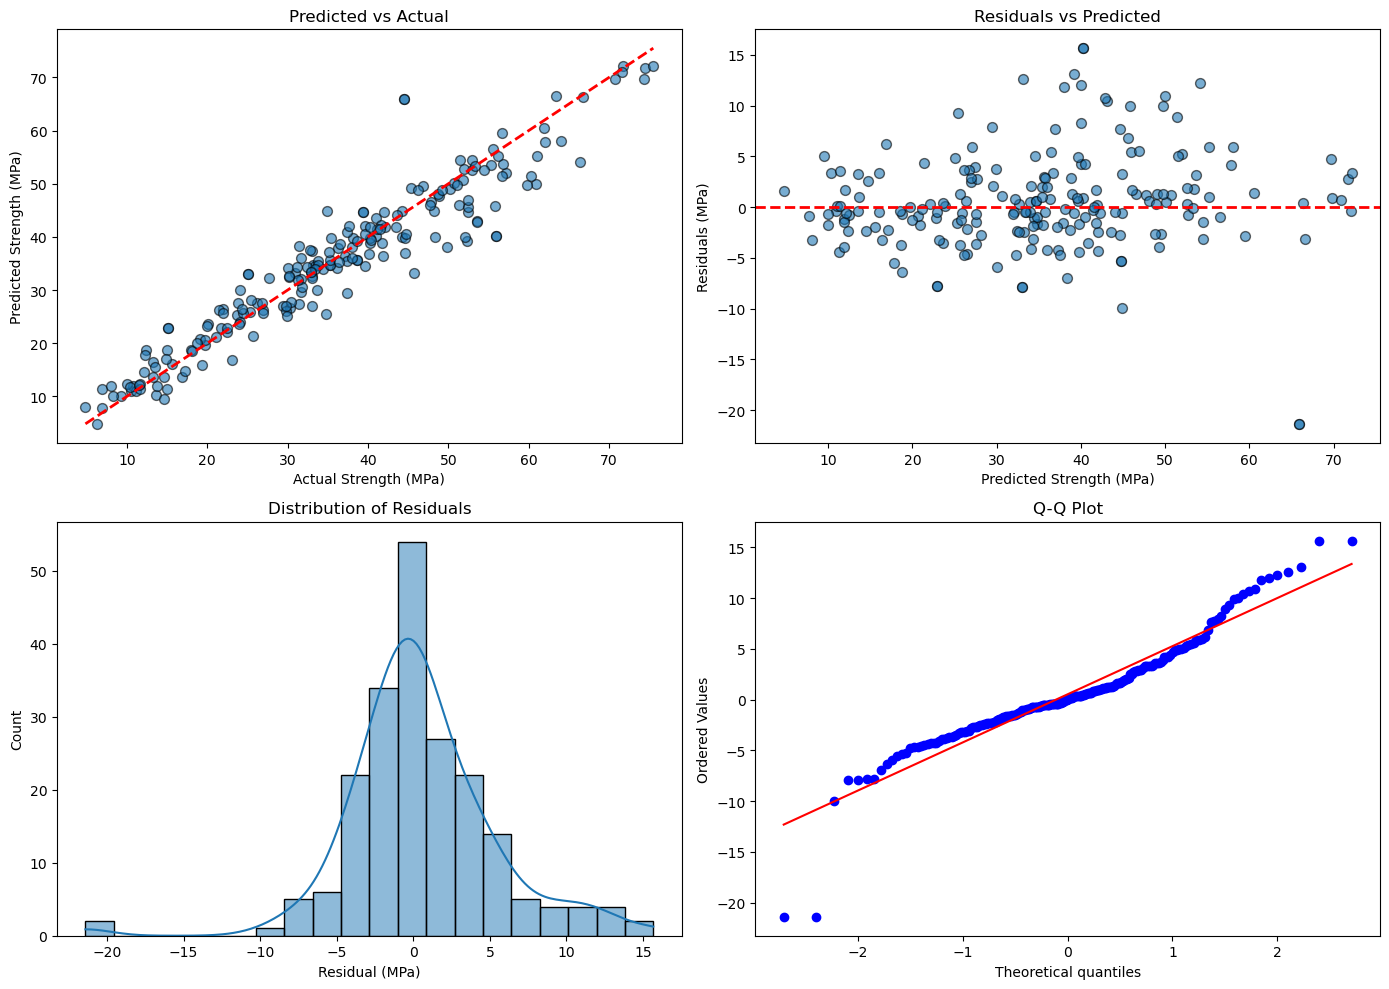


Residual Mean: 0.5294
Residual Std:  4.9007


In [73]:
print("\n" + "="*60)
print(f"RESIDUAL ANALYSIS: {best_model_info['model_name']} on {best_model_info['feature_set']}")
print(f"R² = {best_model_info['r2']:.4f}")
print("="*60)

y_test_best = best_model_info['y_test']
y_pred_best = best_model_info['y_pred']
residuals = y_test_best - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicted vs Actual
axes[0, 0].scatter(y_test_best, y_pred_best, alpha=0.6, edgecolors='k', s=50)
axes[0, 0].plot([y_test_best.min(), y_test_best.max()], 
                [y_test_best.min(), y_test_best.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Strength (MPa)')
axes[0, 0].set_ylabel('Predicted Strength (MPa)')
axes[0, 0].set_title('Predicted vs Actual')

# Residuals vs Predicted
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.6, edgecolors='k', s=50)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Strength (MPa)')
axes[0, 1].set_ylabel('Residuals (MPa)')
axes[0, 1].set_title('Residuals vs Predicted')

# Histogram of Residuals
sns.histplot(residuals, bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_xlabel('Residual (MPa)')
axes[1, 0].set_title('Distribution of Residuals')

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"\nResidual Mean: {residuals.mean():.4f}")
print(f"Residual Std:  {residuals.std():.4f}")

- Predicted vs. Actual: The points follow the line quite closely. This tells us your model is generally accurate
- The scatter plot reveals a cone-shaped spread increasing with predicted strength, indicating heteroscedasticity where variability grows at higher values, suggesting reduced model precision for stronger concrete.
- A single outlier stands out in the bottom right, showing a large negative residual that signals a significant overestimation.
- The histogram of residuals approximates a bell curve centered near zero, hinting at approximate normality despite the uneven variance
- The residuals exhibit a roughly normal shape centered near zero, yet reveal a pronounced leftward skew with notable bars at -20 and -22. This indicates the model frequently overestimates strength in certain instances, producing predictions significantly higher than actual values.
- The Q-Q plot confirms near-normality for most data points, aligning closely with the theoretical distribution in the central region. Together, these patterns suggest consistent overprediction in specific cases, particularly where actual outcomes are much lower than anticipated..

### Feature Importance


FEATURE IMPORTANCE / COEFFICIENTS

Random Forest Feature Importances:
           Feature  Importance
      Total_Binder    0.366075
           Log_Age    0.347958
Water_Cement_ratio    0.207840
  Superplasticizer    0.043541
   Aggregate_ratio    0.034586


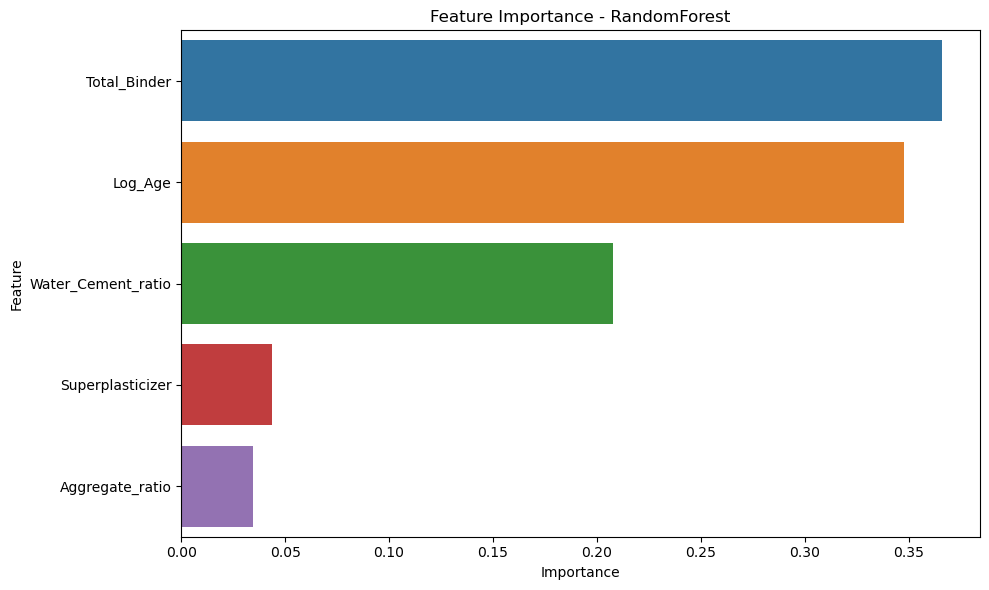

In [74]:
# ============================================================
# 8. FEATURE IMPORTANCE / COEFFICIENTS
# ============================================================
print("\n" + "="*60)
print("FEATURE IMPORTANCE / COEFFICIENTS")
print("="*60)

best_model = best_model_info['model']

if hasattr(best_model, 'feature_importances_'):
    # Random Forest — get feature names from the DataFrame it was trained on
    # The model stores them in feature_names_in_ (sklearn >= 1.0)
    if hasattr(best_model, 'feature_names_in_'):
        feature_names = best_model.feature_names_in_
    else:
        # Fallback: use the feature list from best_model_info
        feature_names = best_model_info['features']
    
    importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nRandom Forest Feature Importances:")
    print(importance.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance, x='Importance', y='Feature')
    plt.title(f'Feature Importance - {best_model_info["model_name"]}')
    plt.tight_layout()
    plt.show()
    
else:
    # Linear model coefficients
    coefs = pd.DataFrame({
        'Feature': best_model_info['features'],
        'Coefficient': best_model.coef_,
        'Abs_Coef': np.abs(best_model.coef_)
    }).sort_values('Abs_Coef', ascending=False)
    print("\nLinear Model Coefficients (standardized features):")
    print(coefs.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=coefs, x='Coefficient', y='Feature')
    plt.title(f'Coefficients - {best_model_info["model_name"]}')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.tight_layout()
    plt.show()

In [75]:
best_row = results_df.iloc[0]
print(f"Best Overall Model: {best_row['Model']} on {best_row['Feature_Set']} features")
print(f"R² = {best_row['R2']:.4f} | RMSE = {best_row['RMSE']:.3f} MPa | MAE = {best_row['MAE']:.3f} MPa")
print(f"CV_RMSE = {best_row['CV_RMSE_mean']:.3f} ± {best_row['CV_RMSE_std']:.3f}")

if best_row['Model'].startswith('Ridge'):
    print("\nRidge regression handled multicollinearity effectively,")
    print("allowing use of all features without VIF-based dropping.")
elif best_row['Model'] == 'LinearRegression':
    print("\nOLS performed best with clean features. VIF-based feature")
    print("selection successfully eliminated multicollinearity.")
else:
    print("\nRandom Forest captured non-linear relationships.")

Best Overall Model: RandomForest on all_features features
R² = 0.9062 | RMSE = 4.917 MPa | MAE = 3.376 MPa
CV_RMSE = 5.171 ± 0.645

Random Forest captured non-linear relationships.


### OUTLIER INVESTIGATION

In [76]:
#  residuals from the best model
y_test_best = best_model_info['y_test']
y_pred_best = best_model_info['y_pred']
residuals = y_test_best - y_pred_best

In [77]:
# investigation dataframe 
X_test_best = best_model_info['X_test'].copy()
X_test_best['Actual'] = y_test_best.values
X_test_best['Predicted'] = y_pred_best
X_test_best['Residual'] = residuals.values
X_test_best['Abs_Residual'] = np.abs(residuals.values)

In [78]:
# Top 10 worst predictions
worst = X_test_best.sort_values('Abs_Residual', ascending=False).head(10)

In [79]:
worst

,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Water_Cement_ratio,Total_Binder,Water_Binder_ratio,Aggregate_ratio,Log_Age,Actual,Predicted,Residual,Abs_Residual
971,312.7,144.7,0.0,127.3,8.0,999.7,822.2,28,0.407099,457.4,0.278312,0.822447,3.367296,44.52,65.930108,-21.410108,21.410108
908,313.0,145.0,0.0,127.0,8.0,1000.0,822.0,28,0.405751,458.0,0.277293,0.822000,3.367296,44.52,65.910608,-21.390608,21.390608
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,0.454771,551.6,0.298949,0.800042,2.079442,55.90,40.232686,15.667314,15.667314
106,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,0.454771,551.6,0.298949,0.800042,2.079442,55.90,40.232686,15.667314,15.667314
394,405.0,0.0,0.0,175.0,0.0,1120.0,695.0,28,0.432099,405.0,0.432099,0.620536,3.367296,52.30,39.189700,13.110300,13.110300
231,213.7,98.1,24.5,181.7,6.9,1065.8,785.4,28,0.850257,336.3,0.540291,0.736911,3.367296,45.71,33.129100,12.580900,12.580900
333,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,100,0.580632,371.9,0.385319,0.736934,4.615121,66.42,54.144700,12.275300,12.275300
478,446.0,24.0,79.0,162.0,11.6,967.0,712.0,7,0.363229,549.0,0.295082,0.736298,2.079442,52.01,40.004278,12.005722,12.005722
107,323.7,282.8,0.0,183.8,10.3,942.7,659.9,7,0.567810,606.5,0.303050,0.700011,2.079442,49.80,38.005683,11.794317,11.794317
328,252.3,0.0,98.8,146.3,14.2,987.8,889.0,100,0.579865,351.1,0.416690,0.899980,4.615121,60.95,50.037000,10.913000,10.913000


In [80]:
print(worst[['Actual', 'Predicted', 'Residual'] + 
             list(best_model_info['X_test'].columns)].round(3))

     Actual  Predicted  Residual  Cement   Slag  FlyAsh  Water  \
971   44.52     65.930   -21.410   312.7  144.7     0.0  127.3   
908   44.52     65.911   -21.391   313.0  145.0     0.0  127.0   
109   55.90     40.233    15.667   362.6  189.0     0.0  164.9   
106   55.90     40.233    15.667   362.6  189.0     0.0  164.9   
394   52.30     39.190    13.110   405.0    0.0     0.0  175.0   
231   45.71     33.129    12.581   213.7   98.1    24.5  181.7   
333   66.42     54.145    12.275   246.8    0.0   125.1  143.3   
478   52.01     40.004    12.006   446.0   24.0    79.0  162.0   
107   49.80     38.006    11.794   323.7  282.8     0.0  183.8   
328   60.95     50.037    10.913   252.3    0.0    98.8  146.3   

     Superplasticizer  CoarseAggregate  FineAggregate  Age  \
971               8.0            999.7          822.2   28   
908               8.0           1000.0          822.0   28   
109              11.6            944.7          755.8    7   
106              11.6    

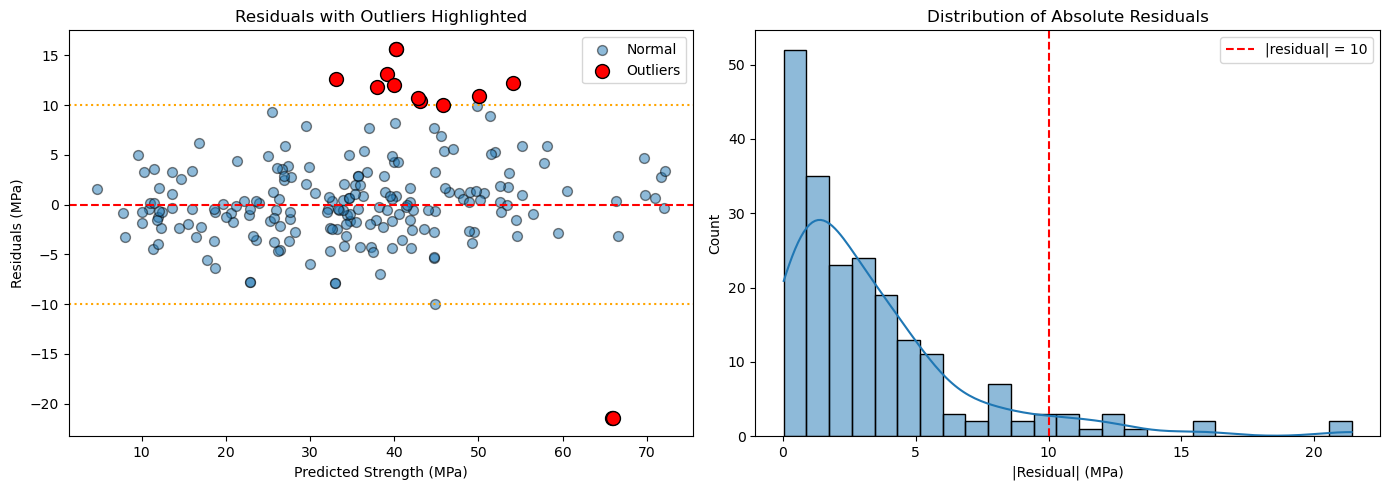

In [81]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals with outliers highlighted
outlier_mask = np.abs(residuals) > 10
axes[0].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='k', s=50, label='Normal')
axes[0].scatter(y_pred_best[outlier_mask], residuals[outlier_mask], 
                color='red', s=100, edgecolors='black', label='Outliers', zorder=5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].axhline(y=10, color='orange', linestyle=':')
axes[0].axhline(y=-10, color='orange', linestyle=':')
axes[0].set_xlabel('Predicted Strength (MPa)')
axes[0].set_ylabel('Residuals (MPa)')
axes[0].set_title('Residuals with Outliers Highlighted')
axes[0].legend()


# Absolute residual distribution
sns.histplot(X_test_best['Abs_Residual'], bins=25, kde=True, ax=axes[1])
axes[1].axvline(x=10, color='red', linestyle='--', label='|residual| = 10')
axes[1].set_xlabel('|Residual| (MPa)')
axes[1].set_title('Distribution of Absolute Residuals')
axes[1].legend()

plt.tight_layout()
plt.show()

- We got two catastrphic over-predictions(Predicted ~65Mpa, Residual ~-20)
- The systematic under-predictions of high-strength samples
- The distribution as expected - heavily right-skewed with most residualsa within 5Mpa but with a few big misses that create the long tail

#### Pattern Analysis

In [82]:
outliers = X_test_best[X_test_best['Abs_Residual'] > 10]
normal = X_test_best[X_test_best['Abs_Residual'] <= 10]

print(f"\nOutliers: {len(outliers)} ({len(outliers)/len(X_test_best)*100:.1f}%)")

print("\n=== OUTLIER vs NORMAL: Mean Feature Values ===")
compare = pd.DataFrame({
    'Outlier_Mean': outliers[list(best_model_info['X_test'].columns)].mean(),
    'Normal_Mean': normal[list(best_model_info['X_test'].columns)].mean(),
    'Difference': outliers[list(best_model_info['X_test'].columns)].mean() - 
                  normal[list(best_model_info['X_test'].columns)].mean()
}).round(3)
print(compare.to_string())


Outliers: 13 (6.3%)

=== OUTLIER vs NORMAL: Mean Feature Values ===
                    Outlier_Mean  Normal_Mean  Difference
Cement                   314.346      269.570      44.776
Slag                     103.600       69.864      33.736
FlyAsh                    49.238       58.909      -9.670
Water                    163.446      181.807     -18.361
Superplasticizer           9.262        6.173       3.089
CoarseAggregate          984.877      969.425      15.452
FineAggregate            761.331      780.695     -19.364
Age                       34.769       50.668     -15.899
Water_Cement_ratio         0.541        0.761      -0.220
Total_Binder             467.185      398.343      68.842
Water_Binder_ratio         0.360        0.482      -0.122
Aggregate_ratio            0.774        0.810      -0.036
Log_Age                    3.215        3.257      -0.042


#### Under and Over Predictions

In [83]:
print("\n=== OVER-PREDICTED (Predicted >> Actual) ===")
under = X_test_best[X_test_best['Residual'] < -10]
print(under[['Actual', 'Predicted', 'Residual']].round(2).to_string() if len(under) > 0 else "None")

print("\n=== UNDER-PREDICTED (Actual >> Predicted) ===")
over = X_test_best[X_test_best['Residual'] > 10]
print(over[['Actual', 'Predicted', 'Residual']].round(2).to_string() if len(over) > 0 else "None")


=== OVER-PREDICTED (Predicted >> Actual) ===
     Actual  Predicted  Residual
908   44.52      65.91    -21.39
971   44.52      65.93    -21.41

=== UNDER-PREDICTED (Actual >> Predicted) ===
      Actual  Predicted  Residual
109    55.90      40.23     15.67
107    49.80      38.01     11.79
394    52.30      39.19     13.11
333    66.42      54.14     12.28
328    60.95      50.04     10.91
1001   53.52      43.07     10.45
231    45.71      33.13     12.58
844    53.52      42.81     10.71
106    55.90      40.23     15.67
478    52.01      40.00     12.01
327    55.83      45.83     10.00


In [84]:
df[df['Strength'] == 44.52]

,Cement,Slag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength,Water_Cement_ratio,Total_Binder,Water_Binder_ratio,Aggregate_ratio,Log_Age
522,284.0,15.0,141.0,179.0,5.5,842.0,801.0,56,44.52,0.630282,440.0,0.406818,0.951306,4.043051
908,313.0,145.0,0.0,127.0,8.0,1000.0,822.0,28,44.52,0.405751,458.0,0.277293,0.822000,3.367296
971,312.7,144.7,0.0,127.3,8.0,999.7,822.2,28,44.52,0.407099,457.4,0.278312,0.822447,3.367296


### Conclusion

While the model achieves strong overall performance (R² ≈ 0.91), residual analysis revealed a small subset of outliers with residuals exceeding ±10 MPa. The two largest over-predictions (samples 908 and 971) share nearly identical feature profiles and actual strength values, suggesting either measurement error or unobserved process variables. The remaining outliers primarily represent under-predicted high-strength samples, indicating that the model's tree-based averaging may regress toward the mean for rare high-performance recipes. These findings suggest that incorporating additional process features (curing temperature, mixing time) or using a more expressive model could further reduce tail errors.